In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os

from src.environment import *
from src.physics import *
from objectives.loss import ProxyInformationLoss,ExactInformationLoss
from src.geometry import generate_receptor_indices
from src.plot_helper import *


In [2]:
CONF = {
        "n_units": 2,
        "n_families": 2,
        "k_sub": 5,
        "batch_size": 512,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.
    }

In [3]:
# 1. SETUP
# -----------------------------------------------------
# We use 1 Unit, 1 Family. The receptor is a homopentamer (Unit 0 five times).

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Modules
conc_strategy = LogNormalConcentration(n_families=CONF['n_families'], init_mean=5.0)
env = LigandEnvironment(CONF['n_units'], CONF['n_families'], conc_model=conc_strategy).to(device)

physics = Receptor(CONF["n_units"], CONF["k_sub"]).to(device)
loss_fn = ProxyInformationLoss(cov_weight=CONF['cov_weight']) # Default bandwidth

# Create the receptor identity: [[0, 0, 0, 0, 0]]
#receptor_indices = torch.zeros(1, CONF["k_sub"], dtype=torch.long, device=device)
#receptor_indices = generate_receptor_indices(n_units=CONF['n_units'],k_sub= CONF['k_sub'],n_sensors=2)
receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)
print(receptor_indices)

# Optimizer
optimizer = optim.Adam(list(env.parameters()) + list(physics.parameters()), lr=CONF["lr"])


tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1]])


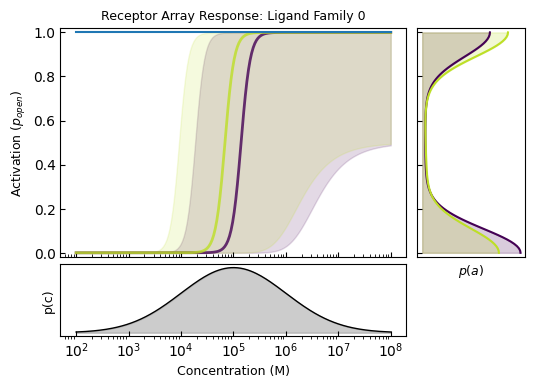

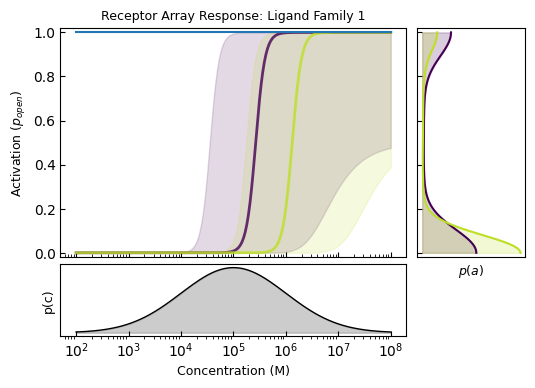

In [4]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)
with torch.no_grad():
    E_o = env.interaction_mu.cpu()[:,:,0]
    E_c = env.interaction_mu.cpu()[:,:,1]
    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
for i in range(axes.__len__()):
    axes[i][0].plot([10**2,10**8],[asymptot[0][i],asymptot[0][i]])

In [5]:
# 3. OPTIMIZATION LOOP
# -----------------------------------------------------
print(f"Training for {CONF['epochs']} epochs...")

stats = []
for epoch in range(CONF['epochs']):
    optimizer.zero_grad()
    
    # A. Sample Batch
    # energies: (B, 1, 2), concs: (B,)
    energies, concs, _ = env.sample_batch(CONF['batch_size'])
    
    # B. Physics
    # activity: (B, 1)
    activity = physics(energies, concs, receptor_indices)
    

    # C. Loss (Maximize Entropy)
    loss = loss_fn(activity)
    
    loss.backward()
    optimizer.step()
    
    
    if epoch % 100 == 0:
        stats.append(loss_fn.make_stats(activity))
stats = np.array(stats)
stats = {
            "full_array_entropy":stats[:,0],
            "marginal_entropy":stats[:,1],
            "total_correlation":stats[:,2]
        }


Training for 600 epochs...


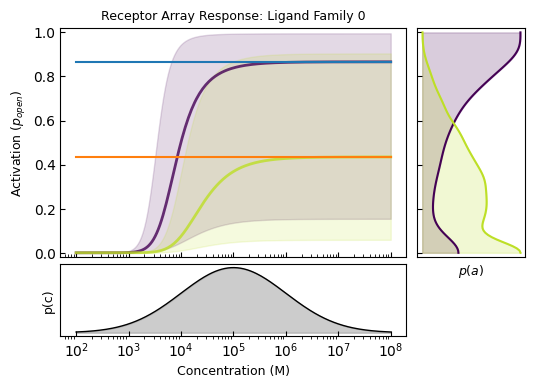

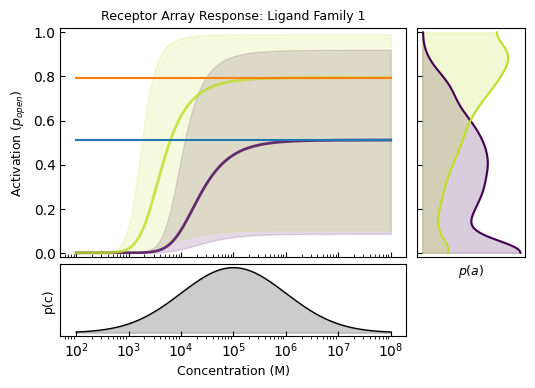

In [6]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)

with torch.no_grad():
    E_o = env.interaction_mu.cpu()[:,:,0]
    E_c = env.interaction_mu.cpu()[:,:,1]
    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
for i in range(axes.__len__()):
    for j in range(asymptot.shape[0]):
        axes[i][0].plot([10**2,10**8],[asymptot[j][i],asymptot[j][i]])

In [7]:
CONF = {
        "n_units": 2,
        "n_families": 2,
        "k_sub": 5,
        "batch_size": 512,
        "epochs": 600,
        "lr": 0.05,
        "k":5
    }
# 1. SETUP
# -----------------------------------------------------
# We use 1 Unit, 1 Family. The receptor is a homopentamer (Unit 0 five times).

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Modules
conc_strategy = LogNormalConcentration(n_families=CONF['n_families'], init_mean=5.0)
env = LigandEnvironment(CONF['n_units'], CONF['n_families'], conc_model=conc_strategy).to(device)

physics = Receptor(CONF["n_units"], CONF["k_sub"]).to(device)
loss_fn = ExactInformationLoss(k=CONF['k']) # Default bandwidth

# Create the receptor identity: [[0, 0, 0, 0, 0]]
#receptor_indices = torch.zeros(1, CONF["k_sub"], dtype=torch.long, device=device)
#receptor_indices = generate_receptor_indices(n_units=CONF['n_units'],k_sub= CONF['k_sub'],n_sensors=2)
receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)

# Optimizer
optimizer = optim.Adam(list(env.parameters()) + list(physics.parameters()), lr=CONF["lr"])

# 3. OPTIMIZATION LOOP
# -----------------------------------------------------
print(f"Training for {CONF['epochs']} epochs...")
exact_loss_history = []

for epoch in range(CONF['epochs']):
    optimizer.zero_grad()
    
    # A. Sample Batch
    # energies: (B, 1, 2), concs: (B,)
    energies, concs, _ = env.sample_batch(CONF['batch_size'])
    
    # B. Physics
    # activity: (B, 1)
    activity = physics(energies, concs, receptor_indices)
    

    # C. Loss (Maximize Entropy)
    loss, stats = loss_fn(activity)
    
    loss.backward()
    optimizer.step()
    
    cpu_stats = [v.detach().cpu().item() for v in stats.values()]
    exact_loss_history.append(cpu_stats)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Entropy = {stats['true_joint_h'].item():.4f}")
exact_loss_history = np.array(exact_loss_history)
exact_loss_history = {
            "loss": exact_loss_history[:,0],
            "true_joint_h": exact_loss_history[:,1],
            "total_correlation": exact_loss_history[:,2]
        }


Training for 600 epochs...
Epoch 0: Entropy = -12.6540
Epoch 100: Entropy = -6.1433
Epoch 200: Entropy = -4.1040
Epoch 300: Entropy = -1.7164
Epoch 400: Entropy = -0.5995
Epoch 500: Entropy = -0.2832


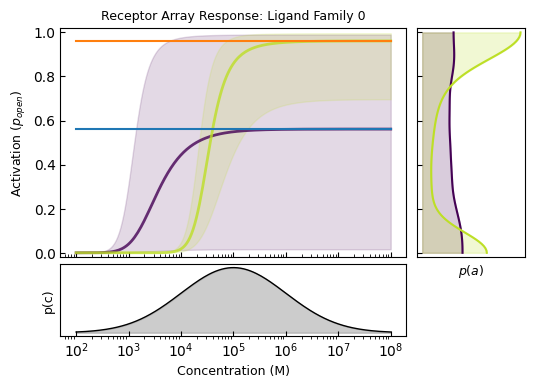

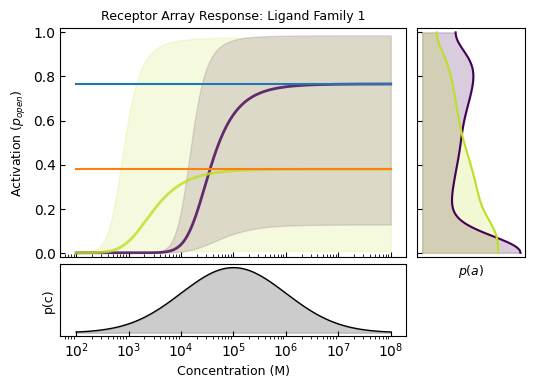

In [8]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)

with torch.no_grad():
    E_o = env.interaction_mu.cpu()[:,:,0]
    E_c = env.interaction_mu.cpu()[:,:,1]
    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
for i in range(axes.__len__()):
    for j in range(asymptot.shape[0]):
        axes[i][0].plot([10**2,10**8],[asymptot[j][i],asymptot[j][i]])

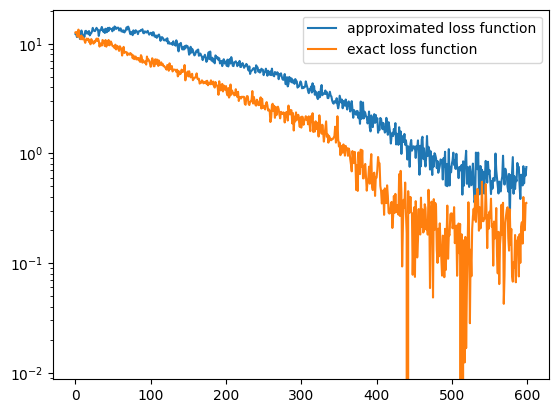

In [9]:
plt.plot(-proxy_loss_history['true_joint_h'],label='approximated loss function')
plt.plot(-exact_loss_history['true_joint_h'],label='exact loss function')
plt.yscale('log')
plt.legend()